In [1]:
import os

os.makedirs("../csv", exist_ok=True)
os.makedirs("../svg", exist_ok=True)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
import pandas as pd
import numpy as np
from scipy.stats import theilslopes
from scipy.stats import gmean


In [3]:
plt.rcParams.update({
    'font.family': 'TeX Gyre Termes',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'figure.dpi': 300,
    'savefig.dpi': 300,
})

In [4]:
TEXTWIDTH_PT = 426.79137
TEXTHEIGHT_PT = 702.78308
PT_PER_INCH = 72.27

FIG_WIDTH = TEXTWIDTH_PT / PT_PER_INCH
FIG_HEIGHT_1 = TEXTHEIGHT_PT / PT_PER_INCH
FIG_HEIGHT_2 = FIG_HEIGHT_1 / 2
FIG_HEIGHT_3 = FIG_HEIGHT_1 / 3
FIG_HEIGHT_4 = FIG_HEIGHT_1 / 4
FIG_HEIGHT_5 = FIG_HEIGHT_1 / 5
FIG_HEIGHT_6 = FIG_HEIGHT_1 / 6
FIG_HEIGHT_7 = FIG_HEIGHT_1 / 7
FIG_HEIGHT_8 = FIG_HEIGHT_1 / 8

In [5]:
operacje_pl = {
    'decrypt': 'deszyfrowanie',
    'encrypt': 'szyfrowanie',
    'encrypt_inflight': 'szyfrowanie\nw locie',
}
backendy_pl = {
    'scalar': 'skalarny',
    'sse2': 'SSE2',
    'avx2': 'AVX2',
    'avx512': 'AVX-512',
    'neon': 'NEON',
}

In [6]:
ciretrion_x86 = pd.read_csv('../data/criterion_x86.csv')
ciretrion_aarch64 = pd.read_csv('../data/criterion_aarch64.csv')
ciretrion = pd.concat([ciretrion_x86, ciretrion_aarch64], ignore_index=True)
ciretrion

,row_index,benchmark,backend,architecture,function,version,suffix,throughput_num,throughput_type,sample_measured_value,unit,iteration_count
0,0,compare,avx512,x86_64,ecb,128_128,2.0,4294967296,elements,7.120750e+09,ns,2
1,1,compare,avx512,x86_64,ecb,128_128,2.0,4294967296,elements,7.119443e+09,ns,2
2,2,compare,avx512,x86_64,ecb,128_128,2.0,4294967296,elements,7.126323e+09,ns,2
3,3,compare,avx512,x86_64,ecb,128_128,2.0,4294967296,elements,7.141047e+09,ns,2
4,4,compare,avx512,x86_64,ecb,128_128,2.0,4294967296,elements,7.148020e+09,ns,2
...,...,...,...,...,...,...,...,...,...,...,...,...
30835,95,speck,neon,aarch64,decrypt,32_64,NaN,8,elements,9.581483e+07,ns,1886208
30836,96,speck,neon,aarch64,decrypt,32_64,NaN,8,elements,9.692608e+07,ns,1905856
30837,97,speck,neon,aarch64,decrypt,32_64,NaN,8,elements,9.903271e+07,ns,1925504
30838,98,speck,neon,aarch64,decrypt,32_64,NaN,8,elements,9.938304e+07,ns,1945152


In [7]:
speck = ciretrion[ciretrion['benchmark'] == 'speck']
speck = speck.drop(columns=['benchmark', 'suffix', 'unit', 'throughput_type'])
speck['time_per_iter_ns'] = speck['sample_measured_value'] / speck['iteration_count']

speck['keys_per_sec'] = (
        speck['throughput_num'] / (speck['time_per_iter_ns'] / 1e9)
)
speck

,row_index,backend,architecture,function,version,throughput_num,sample_measured_value,iteration_count,time_per_iter_ns,keys_per_sec
8520,0,avx512,x86_64,decrypt,128_256,8,984572.0,12159,80.974751,9.879623e+07
8521,1,avx512,x86_64,decrypt,128_256,8,1985845.0,24318,81.661526,9.796535e+07
8522,2,avx512,x86_64,decrypt,128_256,8,2972882.0,36477,81.500178,9.815929e+07
8523,3,avx512,x86_64,decrypt,128_256,8,3996917.0,48636,82.180216,9.734703e+07
8524,4,avx512,x86_64,decrypt,128_256,8,4937627.0,60795,81.217649,9.850076e+07
...,...,...,...,...,...,...,...,...,...,...
30835,95,neon,aarch64,decrypt,32_64,8,95814833.0,1886208,50.797597,1.574878e+08
30836,96,neon,aarch64,decrypt,32_64,8,96926084.0,1905856,50.856982,1.573039e+08
30837,97,neon,aarch64,decrypt,32_64,8,99032708.0,1925504,51.432097,1.555449e+08
30838,98,neon,aarch64,decrypt,32_64,8,99383042.0,1945152,51.092687,1.565782e+08


In [8]:
group_cols = ['backend', 'architecture', 'function', 'version']
results = []

for keys, group in speck.groupby(group_cols):
    x = group['iteration_count'].values
    y = group['sample_measured_value'].values

    slope, intercept, ci_low, ci_high = theilslopes(y, x, 0.95)

    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot

    keys_per_iter = group['throughput_num'].iloc[0]
    keys_per_sec = keys_per_iter / (slope / 1e9)

    results.append({
        **dict(zip(group_cols, keys)),
        'time_per_iter_ns': slope,
        'ci_95_low_ns': ci_low,
        'ci_95_high_ns': ci_high,
        'intercept_ns': intercept,
        'r2': r2,
        'keys_per_sec': keys_per_sec,
        'Mkeys_per_sec': keys_per_sec / 1e6,
    })

speck_reg = pd.DataFrame(results)
speck_reg

,backend,architecture,function,version,time_per_iter_ns,ci_95_low_ns,ci_95_high_ns,intercept_ns,r2,keys_per_sec,Mkeys_per_sec
0,avx2,x86_64,decrypt,128_128,65.516821,65.330165,65.614010,9.540654e+04,0.999851,6.105302e+07,61.053023
1,avx2,x86_64,decrypt,128_192,63.725242,63.662593,63.804609,-1.761331e+05,0.999776,6.276948e+07,62.769476
2,avx2,x86_64,decrypt,128_256,65.568881,65.432537,65.656858,-1.604155e+05,0.999839,6.100455e+07,61.004549
3,avx2,x86_64,decrypt,32_64,38.488781,38.410022,38.553164,9.051430e+03,0.999853,4.157056e+08,415.705551
4,avx2,x86_64,decrypt,48_72,50.752932,50.737573,50.753069,-8.166015e+04,0.999992,1.576264e+08,157.626360
...,...,...,...,...,...,...,...,...,...,...,...
175,sse2,x86_64,encrypt_inflight,48_96,32.260761,32.252801,32.274489,-7.823977e+04,0.999822,1.239896e+08,123.989635
176,sse2,x86_64,encrypt_inflight,64_128,32.384165,32.355343,32.395950,1.197307e+06,0.996257,1.235172e+08,123.517158
177,sse2,x86_64,encrypt_inflight,64_96,26.937457,26.932053,26.942187,9.611883e+06,0.908537,1.484921e+08,148.492118
178,sse2,x86_64,encrypt_inflight,96_144,61.582298,61.578221,61.592353,5.599779e+01,0.999953,3.247687e+07,32.476865


In [9]:
print(f"Min R^2: {speck_reg['r2'].min():.6f}")
print(f"Czy wszystkie > 0.99: {(speck_reg['r2'] > 0.99).all()}")

print(speck_reg[speck_reg['r2'] <= 0.99][['backend', 'architecture', 'backend', 'function', 'version', 'r2']])

Min R^2: 0.908537
Czy wszystkie > 0.99: False
    backend architecture backend          function  version        r2
152    sse2       x86_64    sse2           decrypt  128_256  0.988257
156    sse2       x86_64    sse2           decrypt   64_128  0.983569
177    sse2       x86_64    sse2  encrypt_inflight    64_96  0.908537


In [10]:
version_order = ['32_64', '48_72', '48_96', '64_96', '64_128', '96_96', '96_144', '128_128', '128_192', '128_256']

def make_speck_pivot(df, backend_order):
    pivot = df.pivot_table(
        index=['backend', 'version'],
        columns='function',
        values='Mkeys_per_sec'
    ).round(2).reset_index()
    pivot.columns.name = None
    pivot['backend'] = pd.Categorical(pivot['backend'], categories=backend_order, ordered=True)
    pivot['version'] = pd.Categorical(pivot['version'], categories=version_order, ordered=True)
    return pivot.sort_values(['backend', 'version']).reset_index(drop=True)

speck_pivot_x86 = make_speck_pivot(
    speck_reg[speck_reg['architecture'] == 'x86_64'],
    ['scalar', 'sse2', 'avx2', 'avx512']
)
speck_pivot_aarch64 = make_speck_pivot(
    speck_reg[speck_reg['architecture'] == 'aarch64'],
    ['scalar', 'neon']
)

In [11]:
speck_pivot_x86

,backend,version,decrypt,encrypt,encrypt_inflight
0,scalar,32_64,37.50,64.11,64.11
1,scalar,48_72,18.01,33.17,37.20
2,scalar,48_96,17.14,31.07,32.06
3,scalar,64_96,28.05,39.04,39.06
4,scalar,64_128,26.96,36.40,35.92
5,scalar,96_96,11.91,24.66,24.78
6,scalar,96_144,12.22,22.40,23.25
7,scalar,128_128,18.20,43.71,44.29
8,scalar,128_192,19.40,37.33,39.69
9,scalar,128_256,20.25,34.44,41.26


In [12]:
speck_pivot_aarch64

,backend,version,decrypt,encrypt,encrypt_inflight
0,scalar,32_64,22.91,40.77,45.00
1,scalar,48_72,23.41,34.69,40.03
2,scalar,48_96,22.14,33.20,38.04
3,scalar,64_96,29.48,54.25,54.40
4,scalar,64_128,28.18,52.00,51.81
5,scalar,96_96,15.97,24.95,29.09
6,scalar,96_144,16.56,24.46,28.72
7,scalar,128_128,21.51,40.99,28.62
8,scalar,128_192,20.80,40.18,40.22
9,scalar,128_256,19.97,38.84,38.74


In [13]:
for pivot, name in [(speck_pivot_x86, 'x86'), (speck_pivot_aarch64, 'aarch64')]:
    out = pivot.copy()
    out['version'] = out['version'].astype(str).str.replace('_', '/', regex=False)
    out.to_csv(f'../csv/speck_pivot_{name}.csv', index=False)

In [14]:
def make_speck_pivot_mean(pivot, backend_order):
    mean = pivot.groupby('backend')[['decrypt', 'encrypt', 'encrypt_inflight']].agg(gmean).reset_index()
    mean['backend'] = pd.Categorical(mean['backend'], categories=backend_order, ordered=True)
    mean = mean.sort_values('backend')
    return mean.set_index('backend')[['decrypt', 'encrypt', 'encrypt_inflight']]

speck_pivot_mean_x86 = make_speck_pivot_mean(speck_pivot_x86, ['scalar', 'sse2', 'avx2', 'avx512'])
speck_pivot_mean_aarch64 = make_speck_pivot_mean(speck_pivot_aarch64, ['scalar', 'neon'])

speck_pivot_mean_x86

,decrypt,encrypt,encrypt_inflight
backend,,,
scalar,19.767373,35.193031,36.741265
sse2,54.157794,68.799497,84.911501
avx2,107.792209,136.637807,136.581000
avx512,162.959495,182.362878,182.851175


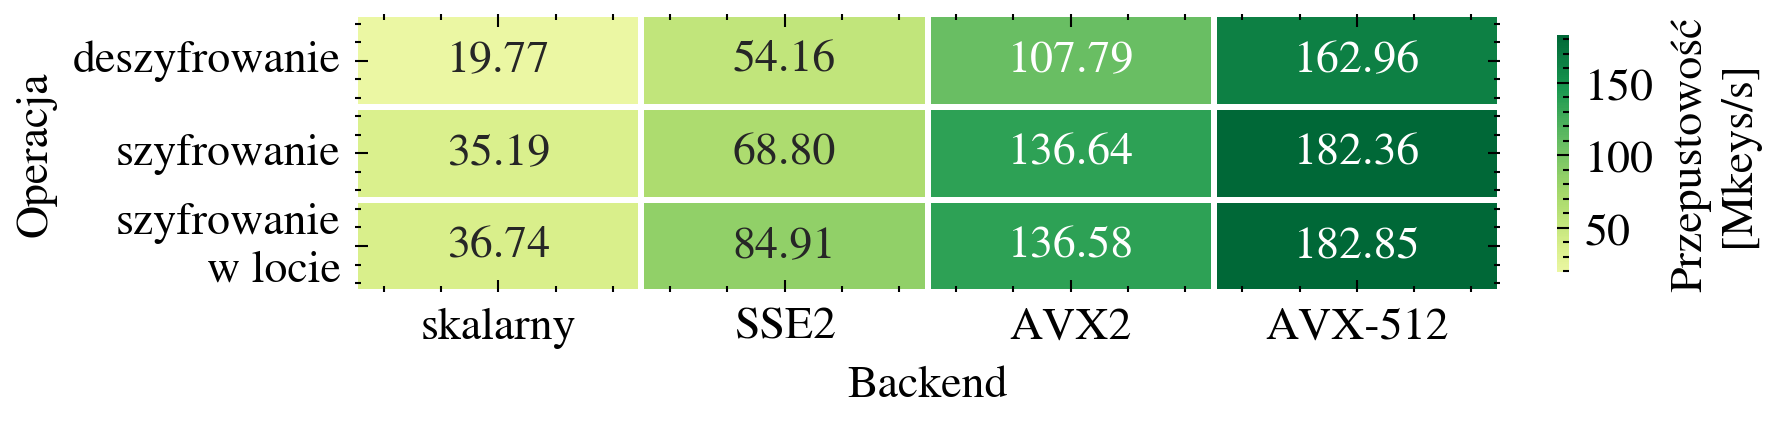

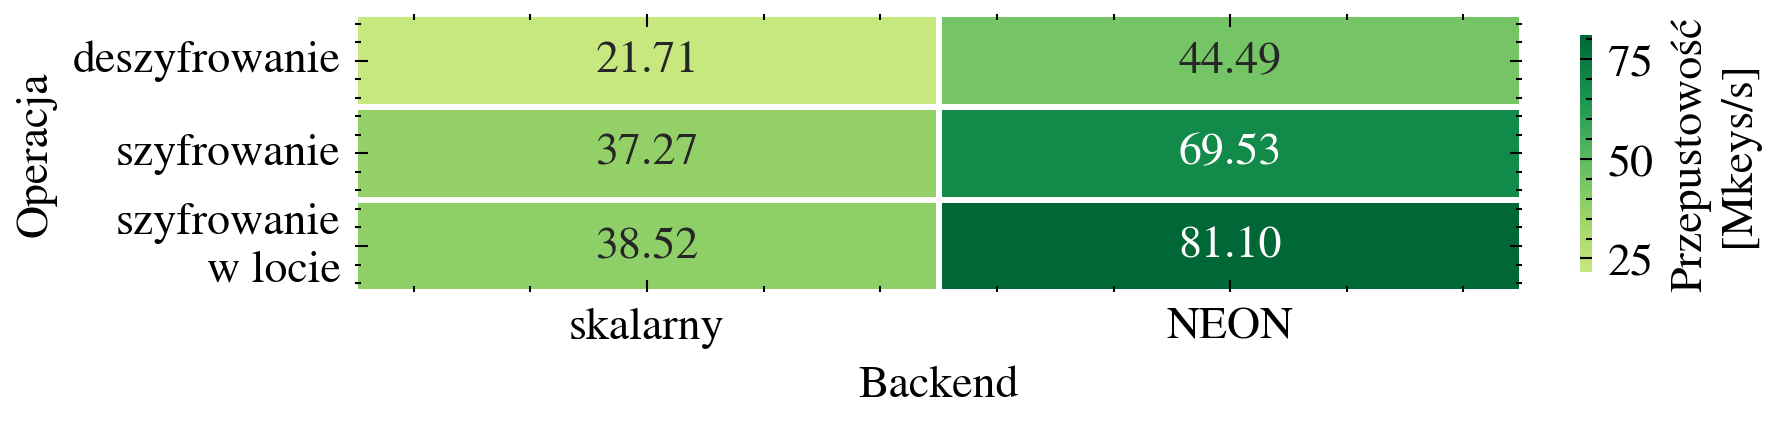

In [15]:
def plot_speck_heatmap(pivot_mean, filename):
    data = pivot_mean.T.rename(index=operacje_pl, columns=backendy_pl)

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT_7), layout='constrained')

        sns.heatmap(
            data,
            ax=ax,
            cmap='RdYlGn',
            center=0,
            annot=True,
            fmt='.2f',
            linewidths=1.0,
            cbar_kws={'label': 'Przepustowość\n[Mkeys/s]', 'shrink': 0.85},
        )

        ax.set_xlabel("Backend")
        ax.set_ylabel('Operacja')

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()

plot_speck_heatmap(speck_pivot_mean_x86, 'speck_pivot_backend_heatmap_x86.svg')
plot_speck_heatmap(speck_pivot_mean_aarch64, 'speck_pivot_backend_heatmap_aarch64.svg')

In [16]:
speck_encrypt_inflight = speck_reg[speck_reg['function'] == 'encrypt_inflight']
speck_encrypt_inflight = speck_encrypt_inflight.drop(columns=['function'])
speck_encrypt_inflight

,backend,architecture,version,time_per_iter_ns,ci_95_low_ns,ci_95_high_ns,intercept_ns,r2,keys_per_sec,Mkeys_per_sec
20,avx2,x86_64,128_128,48.585106,48.475725,48.703990,1.227172e+04,0.999723,8.232976e+07,82.329758
21,avx2,x86_64,128_192,48.299983,48.159651,48.364402,1.144956e+05,0.999732,8.281576e+07,82.815764
22,avx2,x86_64,128_256,49.884649,49.787170,50.036772,-2.074838e+05,0.999834,8.018499e+07,80.184988
23,avx2,x86_64,32_64,27.897347,27.856253,27.932510,-1.311678e+05,0.999680,5.735312e+08,573.531242
24,avx2,x86_64,48_72,41.042866,41.042809,41.082260,1.506139e+04,0.999996,1.949182e+08,194.918162
25,avx2,x86_64,48_96,43.016040,42.981347,43.026779,-5.580490e+04,0.999995,1.859771e+08,185.977137
26,avx2,x86_64,64_128,36.375323,36.301556,36.524576,-2.835119e+05,0.999594,2.199293e+08,219.929319
27,avx2,x86_64,64_96,34.882057,34.775551,34.992431,9.692739e+03,0.999635,2.293443e+08,229.344272
28,avx2,x86_64,96_144,62.331259,62.292131,62.369933,-4.097294e+04,0.999898,6.417326e+07,64.173259
29,avx2,x86_64,96_96,65.145850,65.137432,65.151802,4.665122e+03,0.999996,6.140069e+07,61.400688


In [17]:
def make_speck_backend_speedup(df, backend_order):
    version_order = ['32_64', '48_72', '48_96', '64_96', '64_128', '96_96', '96_144', '128_128', '128_192', '128_256']

    scalar_perf = df[df['backend'] == 'scalar'].set_index('version')['keys_per_sec']
    speedup = df[df['backend'] != 'scalar'].copy()
    speedup['speedup'] = (speedup['keys_per_sec'] / speedup['version'].map(scalar_perf)).round(2)
    speedup = speedup.drop(columns=['time_per_iter_ns', 'ci_95_high_ns', 'ci_95_low_ns', 'intercept_ns', 'r2', 'keys_per_sec', 'Mkeys_per_sec'])

    speedup['backend'] = pd.Categorical(speedup['backend'], categories=backend_order, ordered=True)
    speedup['version'] = pd.Categorical(speedup['version'], categories=version_order, ordered=True)

    speedup = speedup.pivot_table(index='version', columns='backend', values='speedup').reset_index()
    speedup.columns.name = None
    speedup['version'] = speedup['version'].astype(str).str.replace('_', '/', regex=False)
    return speedup.set_index('version')

speck_backend_speedup_x86 = make_speck_backend_speedup(
    speck_encrypt_inflight[speck_encrypt_inflight['architecture'] == 'x86_64'],
    ['sse2', 'avx2', 'avx512']
)
speck_backend_speedup_aarch64 = make_speck_backend_speedup(
    speck_encrypt_inflight[speck_encrypt_inflight['architecture'] == 'aarch64'],
    ['neon']
)

# speck_backend_speedup_x86

speck_backend_speedup = pd.merge(speck_backend_speedup_x86, speck_backend_speedup_aarch64, on='version', how='left')
speck_backend_speedup

,sse2,avx2,avx512,neon
version,,,,
32/64,5.55,8.95,12.05,6.39
48/72,3.32,5.24,5.68,2.45
48/96,3.87,5.80,6.22,2.45
64/96,3.80,5.87,8.15,2.08
64/128,3.44,6.12,8.50,2.08
96/96,1.26,2.48,3.53,1.15
96/144,1.40,2.76,3.95,1.17
128/128,1.27,1.86,2.70,2.51
128/192,1.52,2.09,3.01,1.75


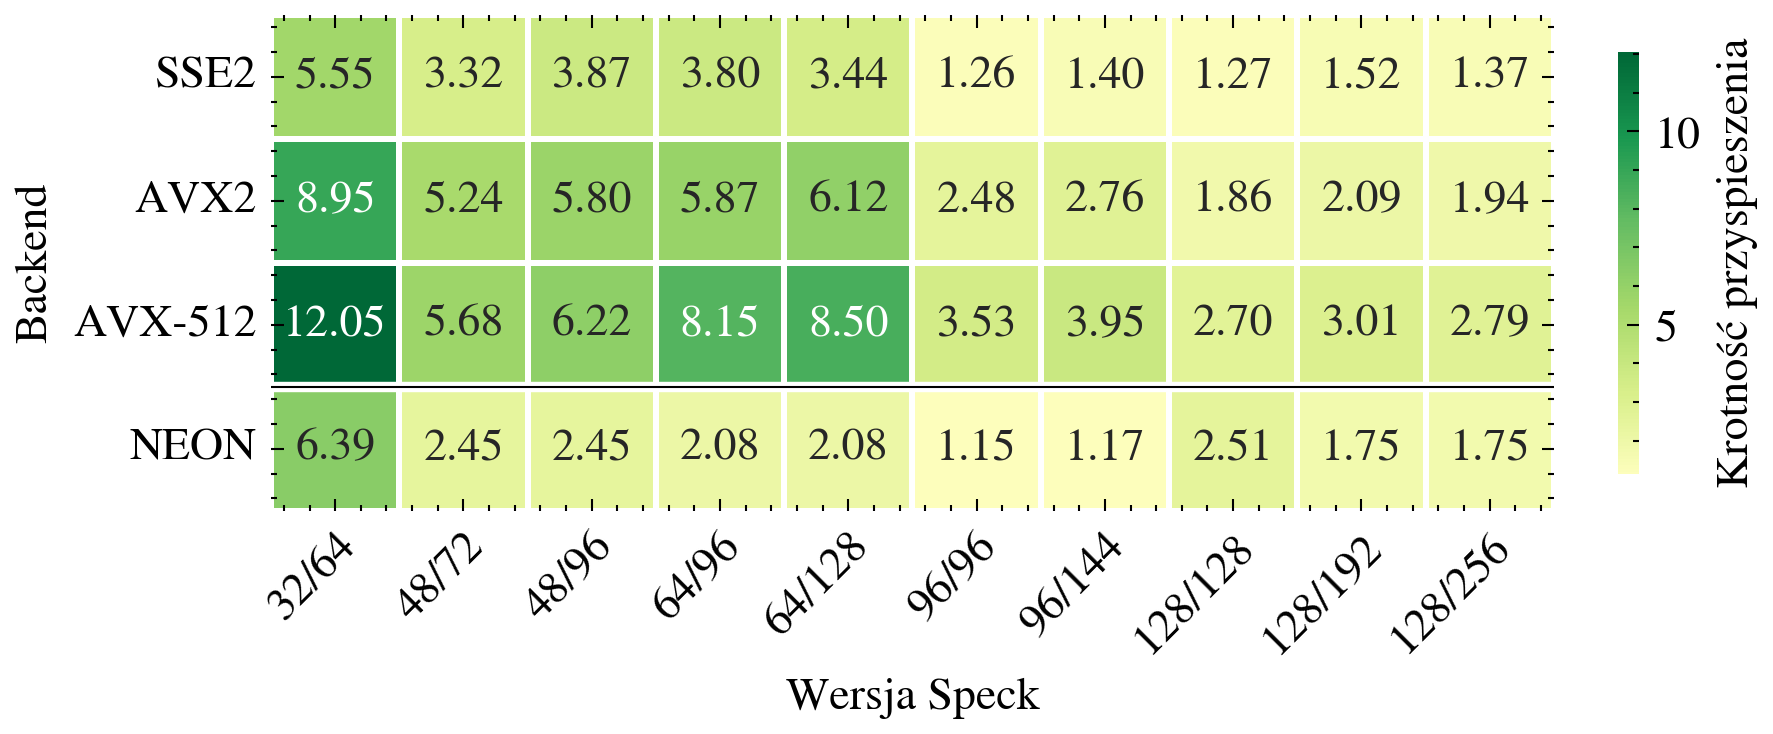

In [18]:
def plot_speck_backend_speedup(speedup, filename, fig_height, label):
    with plt.style.context(['science', 'no-latex', 'bright']):
        data = speedup.T.rename(index=backendy_pl)

        fig, ax = plt.subplots(figsize=(FIG_WIDTH, fig_height), layout='constrained')

        sns.heatmap(
            data,
            ax=ax,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=1,
            linewidths=1.0,
            cbar_kws={'label': label, 'shrink': 0.85},
        )
        ax.set_xlabel('Wersja Speck')
        ax.set_ylabel('Backend')

        ax.axhline(y=3, color='white', linewidth=2.5)
        ax.axhline(y=3, color='black', linewidth=0.5)

        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
        plt.setp(ax.get_yticklabels(), rotation=0)

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()

plot_speck_backend_speedup(speck_backend_speedup, 'speck_backend_speedup.svg', FIG_HEIGHT_4, 'Krotność przyspieszenia')

In [19]:
engine = ciretrion[ciretrion['benchmark'] == 'engine']
engine = engine.drop(columns=['benchmark', 'unit', 'throughput_type', 'function'])
engine['time_per_iter_ns'] = engine['sample_measured_value'] / engine['iteration_count']

engine['keys_per_sec'] = (
        engine['throughput_num'] / (engine['time_per_iter_ns'] / 1e9)
)
engine

,row_index,backend,architecture,version,suffix,throughput_num,sample_measured_value,iteration_count,time_per_iter_ns,keys_per_sec
4920,0,avx512,x86_64,128_256,3.0,16777216,304472555.0,2,152236277.5,1.102051e+08
4921,1,avx512,x86_64,128_256,3.0,16777216,305021893.0,2,152510946.5,1.100066e+08
4922,2,avx512,x86_64,128_256,3.0,16777216,302864346.0,2,151432173.0,1.107903e+08
4923,3,avx512,x86_64,128_256,3.0,16777216,307076225.0,2,153538112.5,1.092707e+08
4924,4,avx512,x86_64,128_256,3.0,16777216,298373485.0,2,149186742.5,1.124578e+08
...,...,...,...,...,...,...,...,...,...,...
24835,25,scalar,aarch64,128_256,3.0,16777216,422878333.0,1,422878333.0,3.967386e+07
24836,26,scalar,aarch64,128_256,3.0,16777216,422682208.0,1,422682208.0,3.969227e+07
24837,27,scalar,aarch64,128_256,3.0,16777216,422786541.0,1,422786541.0,3.968247e+07
24838,28,scalar,aarch64,128_256,3.0,16777216,422999667.0,1,422999667.0,3.966248e+07


In [20]:
import numpy as np
import pandas as pd
from scipy.stats import bootstrap

group_cols = ['backend', 'architecture', 'version', 'suffix']


def analyze_group(group):
    t = (group['sample_measured_value'] / group['iteration_count']).to_numpy()
    n_keys = group['throughput_num'].iloc[0]

    median_ns = np.median(t)
    mad_ns = np.median(np.abs(t - median_ns))
    mad_sigma = 1.4826 * mad_ns

    res_median = bootstrap(
        (t,), np.median,
        n_resamples=10_000,
        confidence_level=0.95,
        method='BCa',
        random_state=0,
    )
    ci_low, ci_high = res_median.confidence_interval

    mkeys_per_sec = n_keys / (median_ns / 1e9) / 1e6
    mkeys_low = n_keys / (ci_high / 1e9) / 1e6
    mkeys_high = n_keys / (ci_low / 1e9) / 1e6

    rel_mad = mad_ns / median_ns
    p05, p95 = np.percentile(t, [5, 95])
    spread = (p95 - p05) / median_ns

    return pd.Series({
        'n_samples': len(t),
        'median_ns': median_ns,
        'ci95_low_ns': ci_low,
        'ci95_high_ns': ci_high,
        'mad_ns': mad_ns,
        'mad_sigma_ns': mad_sigma,
        'rel_mad': rel_mad,
        'spread_p05_p95': spread,
        'Mkeys_per_sec': mkeys_per_sec,
        'Mkeys_per_sec_ci_low': mkeys_low,
        'Mkeys_per_sec_ci_high': mkeys_high,
    })


engine_stats = (
    engine
    .groupby(group_cols)
    .apply(analyze_group, include_groups=False)
    .reset_index()
)
engine_stats

/home/jan/Developer/speck/analysis/.venv/lib/python3.14/site-packages/scipy/stats/_resampling.py:155: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/home/jan/Developer/speck/analysis/.venv/lib/python3.14/site-packages/scipy/_lib/_util.py:365: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


,backend,architecture,version,suffix,n_samples,median_ns,ci95_low_ns,ci95_high_ns,mad_ns,mad_sigma_ns,rel_mad,spread_p05_p95,Mkeys_per_sec,Mkeys_per_sec_ci_low,Mkeys_per_sec_ci_high
0,avx2,x86_64,128_128,1.0,30.0,3.379559e+03,3.376368e+03,3.418652e+03,8.680630e+00,1.286990e+01,0.002569,0.021171,75.749532,74.883321,75.821122
1,avx2,x86_64,128_128,2.0,30.0,8.593079e+05,8.543699e+05,8.649788e+05,6.437557e+03,9.544322e+03,0.007492,0.020590,76.266024,75.766016,76.706821
2,avx2,x86_64,128_128,3.0,30.0,2.231674e+08,2.228566e+08,2.236557e+08,2.362084e+06,3.502026e+06,0.010584,0.034878,75.177709,75.013584,75.282572
3,avx2,x86_64,128_192,1.0,30.0,3.614793e+03,3.579250e+03,3.626538e+03,3.123677e+01,4.631163e+01,0.008641,0.029484,70.820092,70.590732,71.523366
4,avx2,x86_64,128_192,2.0,30.0,9.219523e+05,9.208226e+05,9.296863e+05,6.631992e+03,9.832591e+03,0.007193,0.044535,71.083935,70.492596,71.171150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,sse2,x86_64,96_144,2.0,30.0,1.594316e+06,1.590292e+06,1.596218e+06,5.194476e+03,7.701330e+03,0.003258,0.008809,41.106022,41.057037,41.210039
176,sse2,x86_64,96_144,3.0,30.0,5.225726e+08,5.223010e+08,5.228263e+08,3.366995e+05,4.991907e+05,0.000644,0.001714,32.105044,32.089467,32.121736
177,sse2,x86_64,96_96,1.0,30.0,8.010665e+03,8.006777e+03,8.015143e+03,4.514601e+00,6.693348e+00,0.000564,0.001568,31.957396,31.939544,31.972916
178,sse2,x86_64,96_96,2.0,30.0,1.586440e+06,1.585957e+06,1.586646e+06,5.867075e+02,8.698526e+02,0.000370,0.001194,41.310111,41.304733,41.322692


In [21]:
def make_engine_pivot(df, backend_order):
    pivot = (
        df.pivot_table(
            index=['backend', 'version'],
            columns='suffix',
            values='Mkeys_per_sec',
        )
        .rename(columns={1.0: '1', 2.0: '2', 3.0: '3'})
    ).round(2).reset_index()
    pivot.columns.name = None

    version_order = ['32_64', '48_72', '48_96', '64_96', '64_128', '96_96', '96_144', '128_128', '128_192', '128_256']
    pivot['backend'] = pd.Categorical(pivot['backend'], categories=backend_order, ordered=True)
    pivot['version'] = pd.Categorical(pivot['version'], categories=version_order, ordered=True)
    return pivot.sort_values(['backend', 'version']).reset_index(drop=True)

engine_pivot_x86 = make_engine_pivot(
    engine_stats[engine_stats['architecture'] == 'x86_64'],
    ['scalar', 'sse2', 'avx2', 'avx512']
)
engine_pivot_aarch64 = make_engine_pivot(
    engine_stats[engine_stats['architecture'] == 'aarch64'],
    ['scalar', 'neon']
)

engine_pivot_x86

,backend,version,1,2,3
0,scalar,32_64,67.01,67.15,65.06
1,scalar,48_72,38.48,33.58,33.18
2,scalar,48_96,33.28,32.53,32.28
3,scalar,64_96,44.37,44.19,44.46
4,scalar,64_128,48.65,48.28,48.29
5,scalar,96_96,23.92,24.63,23.66
6,scalar,96_144,24.84,24.70,24.50
7,scalar,128_128,39.52,39.65,39.50
8,scalar,128_192,31.78,32.08,31.94
9,scalar,128_256,36.12,36.23,36.21


In [22]:
for pivot, name in [(engine_pivot_x86, 'x86'), (engine_pivot_aarch64, 'aarch64')]:
    out = pivot.copy()
    out['version'] = out['version'].astype(str).str.replace('_', '/', regex=False)
    out.to_csv(f'../csv/engine_pivot_{name}.csv', index=False)

In [23]:
def make_engine_pivot_mean(pivot, backend_order):
    mean = pivot.groupby('backend')[['1', '2', '3']].agg(gmean).reset_index()
    mean['backend'] = pd.Categorical(mean['backend'], categories=backend_order, ordered=True)
    mean = mean.sort_values('backend')
    return mean.set_index('backend')[['1', '2', '3']]

engine_pivot_mean_x86 = make_engine_pivot_mean(engine_pivot_x86, ['scalar', 'sse2', 'avx2', 'avx512'])
engine_pivot_mean_aarch64 = make_engine_pivot_mean(engine_pivot_aarch64, ['scalar', 'neon'])

engine_pivot_mean_x86

,1,2,3
backend,,,
scalar,37.139509,36.662403,36.290186
sse2,66.841124,65.624225,66.392638
avx2,120.677480,119.102590,119.378203
avx512,178.626332,178.830674,166.529595


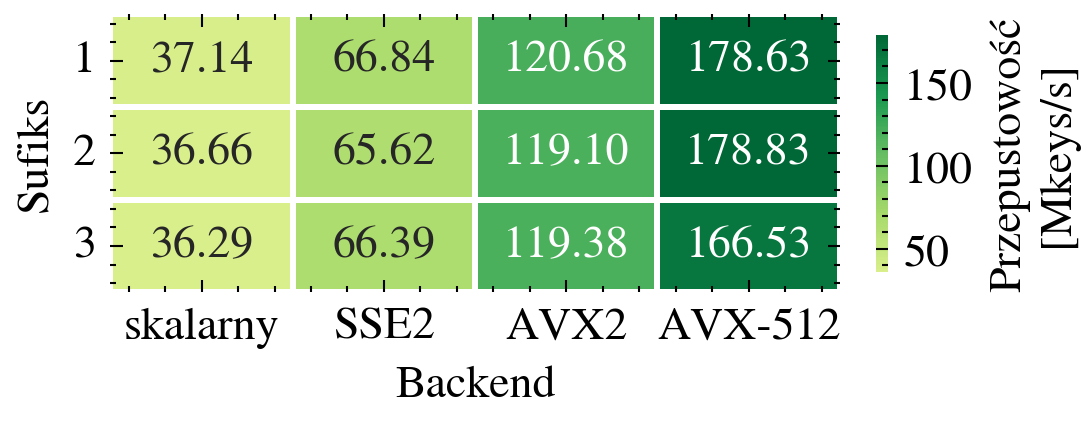

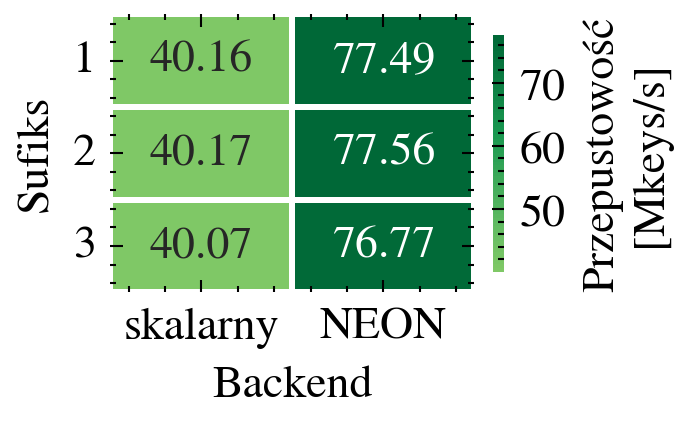

In [24]:
def plot_engine_heatmap(pivot_mean, filename, width):
    data = pivot_mean.T.rename(columns=backendy_pl)

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(width, FIG_HEIGHT_7), layout='constrained')

        sns.heatmap(
            data,
            ax=ax,
            cmap='RdYlGn',
            center=0,
            annot=True,
            fmt='.2f',
            linewidths=1.0,
            cbar_kws={'label': 'Przepustowość\n[Mkeys/s]', 'shrink': 0.85},
        )

        ax.set_xlabel('Backend')
        ax.set_ylabel('Sufiks')

        plt.setp(ax.get_yticklabels(), rotation=0)

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()

plot_engine_heatmap(engine_pivot_mean_x86, 'engine_pivot_backend_heatmap_x86.svg', FIG_WIDTH * 0.615)
plot_engine_heatmap(engine_pivot_mean_aarch64, 'engine_pivot_backend_heatmap_aarch64.svg', FIG_WIDTH * 0.385)

In [25]:
def make_engine_single_backend_pivot(df, architecture, backend):
    version_order = ['32_64', '48_72', '48_96', '64_96', '64_128',
                     '96_96', '96_144', '128_128', '128_192', '128_256']

    pivot = (
        df[(df['architecture'] == architecture) & (df['backend'] == backend)]
        .pivot_table(
            index=['backend', 'version'],
            columns='suffix',
            values='Mkeys_per_sec',
        )
        .rename(columns={1.0: '1', 2.0: '2', 3.0: '3'})
    ).round(2).reset_index()

    pivot.columns.name = None
    pivot['version'] = pd.Categorical(pivot['version'], categories=version_order, ordered=True)
    pivot = pivot.sort_values('version').reset_index(drop=True)
    pivot['version'] = pivot['version'].astype(str).str.replace('_', '/', regex=False)
    return pivot.set_index('version')[['1', '2', '3']]

engine_pivot_avx512 = make_engine_single_backend_pivot(engine_stats, 'x86_64', 'avx512')
engine_pivot_neon   = make_engine_single_backend_pivot(engine_stats, 'aarch64', 'neon')

engine_pivot_avx512


,1,2,3
version,,,
32/64,660.86,633.80,552.53
48/72,252.58,210.70,201.92
48/96,222.57,201.82,184.90
64/96,282.17,287.95,275.85
64/128,287.95,293.44,280.73
96/96,87.98,101.30,85.19
96/144,89.48,101.99,87.45
128/128,114.01,114.62,113.37
128/192,110.95,111.32,110.51


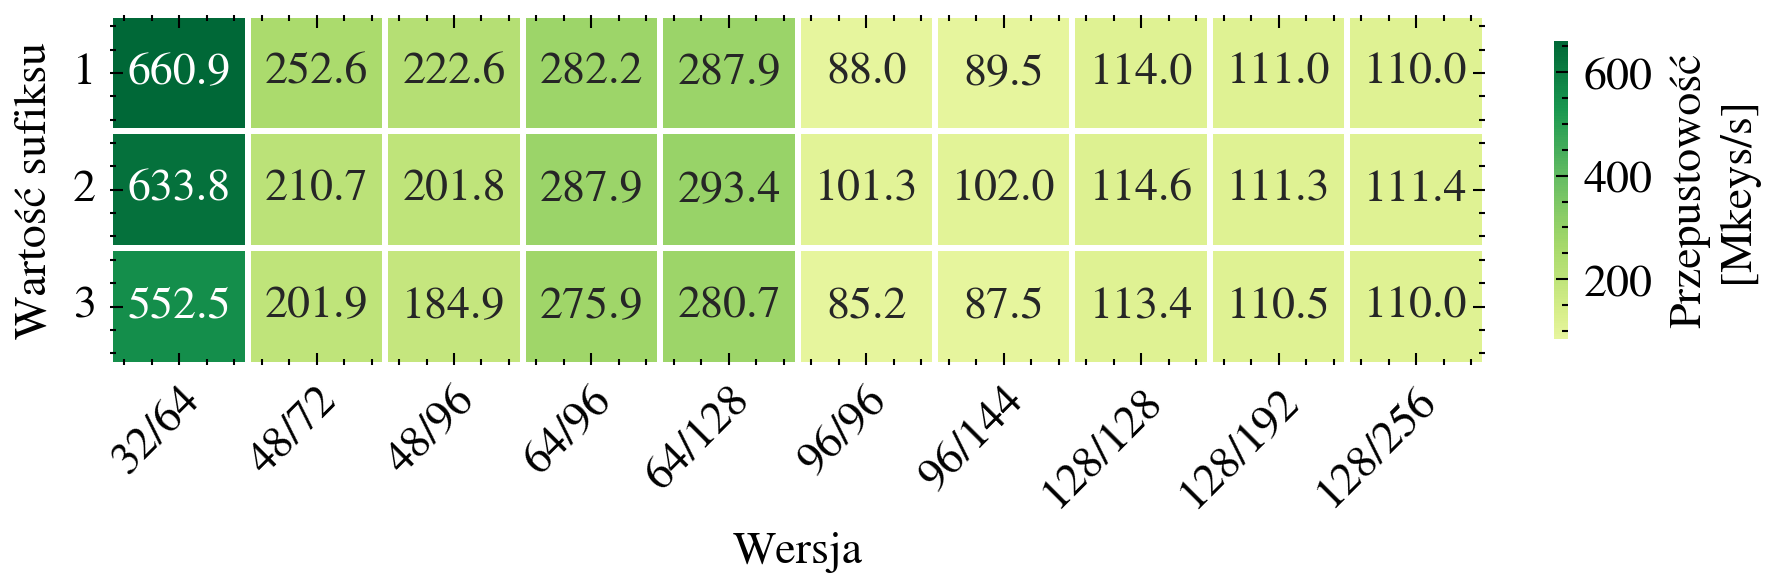

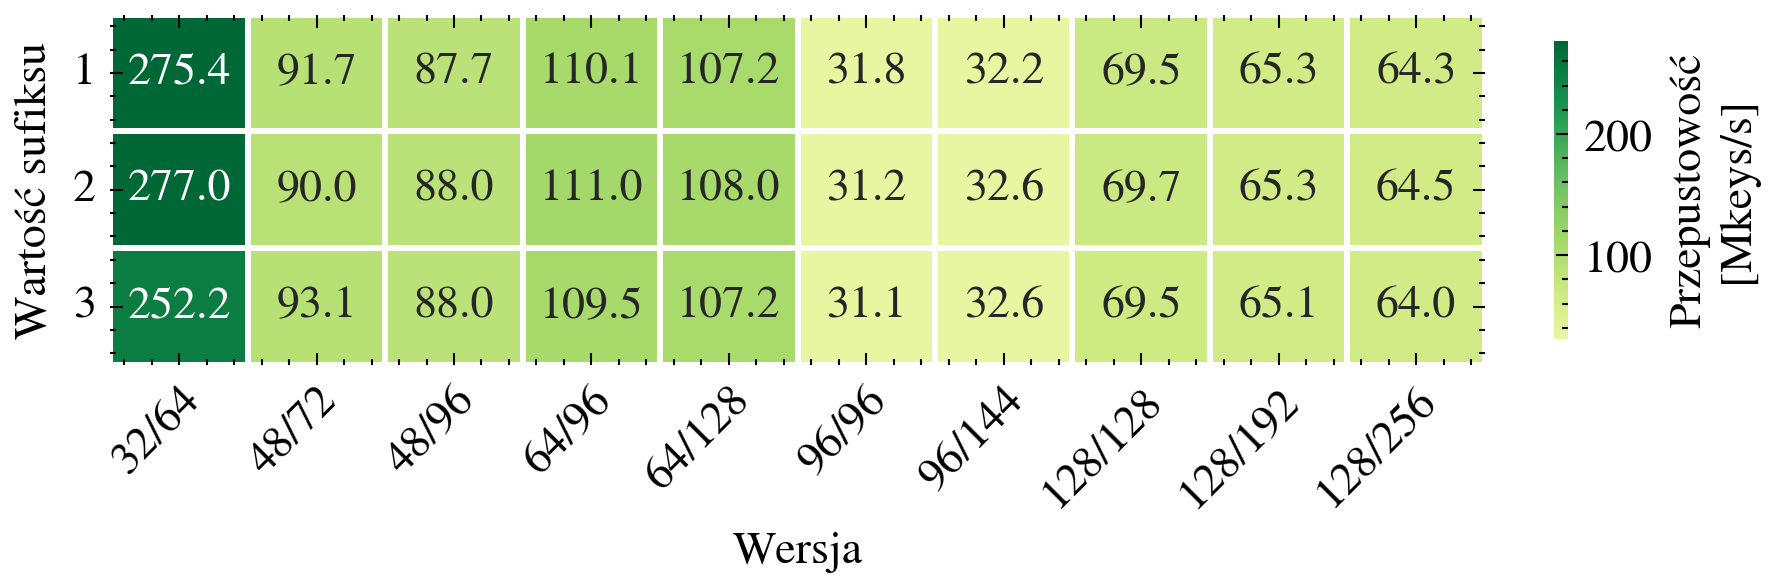

In [26]:
def plot_engine_single_backend_heatmap(pivot, filename):
    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT_5), layout='constrained')

        sns.heatmap(
            pivot.T,
            ax=ax,
            cmap='RdYlGn',
            center=0,
            annot=True,
            fmt='.1f',
            linewidths=1.0,
            cbar_kws={'label': 'Przepustowość\n[Mkeys/s]', 'shrink': 0.85},
        )

        ax.set_xlabel('Wersja')
        ax.set_ylabel('Wartość sufiksu')

        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
        plt.setp(ax.get_yticklabels(), rotation=0)

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()

plot_engine_single_backend_heatmap(engine_pivot_avx512, 'engine_pivot_backend_avx512_heatmap.svg')
plot_engine_single_backend_heatmap(engine_pivot_neon,   'engine_pivot_backend_neon_heatmap.svg')
